In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt


In [51]:
df = pd.read_csv('data/ads.csv')
df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,45-54/unknown,55-64/female,55-64/male,55-64/unknown,65+/female,65+/male,65+/unknown,Unknown/female,Unknown/male,Unknown/unknown
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.02,0.97,1.22,0.01,0.94,0.80,0.01,0.0,0.0,0.0
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,0.02,2.56,5.44,0.06,3.05,3.22,0.04,0.0,0.0,0.0
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.13,19.85,0.25,20.26,12.40,0.25,0.0,0.0,0.0
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.72,19.94,0.25,18.27,10.68,0.25,0.0,0.0,0.0
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,18.72,21.20,0.28,14.66,10.20,0.22,0.0,0.0,0.0


In [52]:
df.columns

Index(['id', 'ad_creation_time', 'ad_delivery_start_time', 'bylines',
       'currency', 'page_id', 'page_name', 'ad_creative_bodies',
       'ad_creative_link_captions', 'ad_creative_link_descriptions',
       'ad_creative_link_titles', 'audience_size_lower', 'impressions_lower',
       'impressions_upper', 'spend_lower', 'spend_upper', 'ad_snapshot_url',
       'language_en', 'language_es', 'language_other', 'platform_fb',
       'platform_ig', 'platform_other', '13-17/female', '13-17/male',
       '13-17/unknown', '18-24/female', '18-24/male', '18-24/unknown',
       '25-34/female', '25-34/male', '25-34/unknown', '35-44/female',
       '35-44/male', '35-44/unknown', '45-54/female', '45-54/male',
       '45-54/unknown', '55-64/female', '55-64/male', '55-64/unknown',
       '65+/female', '65+/male', '65+/unknown', 'Unknown/female',
       'Unknown/male', 'Unknown/unknown'],
      dtype='object')

In [53]:
#TARGET DEMOGRAPHICS

In [ ]:
demo_cols = [c for c in df.columns if '/' in c]

# melt
demo_df = (df.melt(id_vars=['id', 'impressions_lower', 'impressions_upper', 'spend_lower', 'spend_upper'], value_vars=demo_cols))
demo_df[['age_group','gender']] = demo_df['variable'].str.split('/', expand=True)
demo_df = demo_df.drop(columns=['variable'])

demo_df.head()

,id,impressions_lower,impressions_upper,spend_lower,spend_upper,value,age_group,gender
0,1263237120532732,60000,69999.0,100,199.0,0.0,13-17,female
1,2508232389430627,20000,24999.0,0,99.0,0.0,13-17,female
2,156182708989204,60000,69999.0,700,799.0,0.0,13-17,female
3,397644197860634,60000,69999.0,700,799.0,0.0,13-17,female
4,527071631288361,70000,79999.0,700,799.0,0.0,13-17,female


In [55]:
problem_ads = (demo_df.groupby('id')['value'].sum().reset_index())

# will remove the 10,993 entries with less than 0.99 value, since it is missing a lot of demographic data
valid_ids = problem_ads.loc[problem_ads['value'].between(99, 101), 'id']
demo_df_valid = demo_df[demo_df['id'].isin(valid_ids)]

# Remove 'Unknown' age_group since it contributes a negligible share (~13 total percentage points across the dataset)
demo_df_valid = demo_df_valid[demo_df_valid['age_group'] != 'Unknown']

demo_df_valid.head()

,id,impressions_lower,impressions_upper,spend_lower,spend_upper,value,age_group,gender
0,1263237120532732,60000,69999.0,100,199.0,0.0,13-17,female
1,2508232389430627,20000,24999.0,0,99.0,0.0,13-17,female
2,156182708989204,60000,69999.0,700,799.0,0.0,13-17,female
3,397644197860634,60000,69999.0,700,799.0,0.0,13-17,female
4,527071631288361,70000,79999.0,700,799.0,0.0,13-17,female


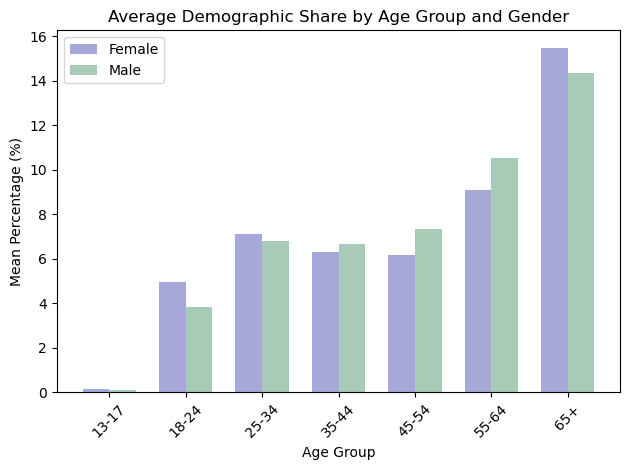

In [56]:
# Compute mean share by age_group and gender
mean_demo = (demo_df_valid.groupby(['age_group', 'gender'], as_index=False).agg({'value': 'mean'}))

# Pivot for grouped bar plotting
pivot_demo = mean_demo.pivot(index='age_group', columns='gender', values='value')

import matplotlib.pyplot as plt
import numpy as np

# Ensure consistent age order (sorted naturally)
pivot_demo = pivot_demo.sort_index()

x = np.arange(len(pivot_demo.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, pivot_demo['female'], width, label='Female', color='#a6a8d8')
plt.bar(x + width/2, pivot_demo['male'], width, label='Male', color='#a8cbb7')

plt.xticks(x, pivot_demo.index, rotation=45)
plt.xlabel('Age Group')
plt.ylabel('Mean Percentage (%)')
plt.title('Average Demographic Share by Age Group and Gender')
plt.legend()

plt.tight_layout()
plt.show()

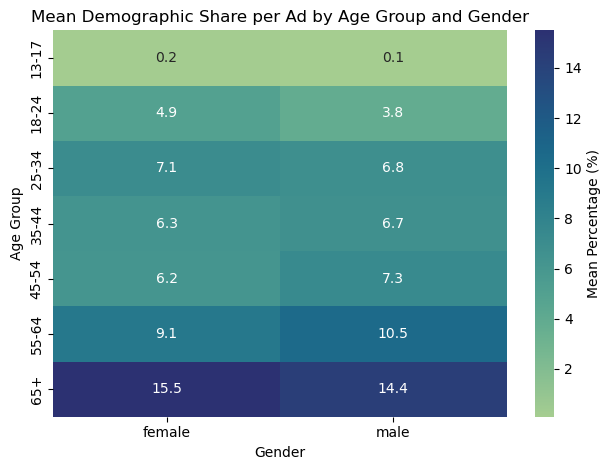

In [57]:
mean_demo_by_age_gender = (demo_df_valid.groupby(['age_group','gender'])['value'].mean().unstack())
mean_demo_by_age_gender = mean_demo_by_age_gender.drop(columns=['unknown'])

ax = sns.heatmap(
    mean_demo_by_age_gender,
    annot=True,
    fmt=".1f",
    cmap="crest"
)

ax.set_title("Mean Demographic Share per Ad by Age Group and Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Age Group")

cbar = ax.collections[0].colorbar
cbar.set_label("Mean Percentage (%)")

plt.tight_layout()
plt.show()

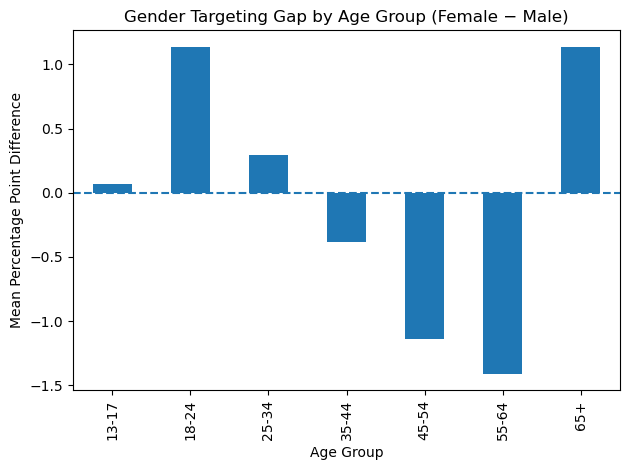

In [58]:
gap = mean_demo_by_age_gender['female'] - mean_demo_by_age_gender['male']

gap.plot(kind='bar')

plt.axhline(0, linestyle='--')
plt.title("Gender Targeting Gap by Age Group (Female − Male)")
plt.ylabel("Mean Percentage Point Difference")
plt.xlabel("Age Group")

plt.tight_layout()
plt.show()

In [59]:
# TIME SERIES ANALYSIS

In [60]:
df.columns

Index(['id', 'ad_creation_time', 'ad_delivery_start_time', 'bylines',
       'currency', 'page_id', 'page_name', 'ad_creative_bodies',
       'ad_creative_link_captions', 'ad_creative_link_descriptions',
       'ad_creative_link_titles', 'audience_size_lower', 'impressions_lower',
       'impressions_upper', 'spend_lower', 'spend_upper', 'ad_snapshot_url',
       'language_en', 'language_es', 'language_other', 'platform_fb',
       'platform_ig', 'platform_other', '13-17/female', '13-17/male',
       '13-17/unknown', '18-24/female', '18-24/male', '18-24/unknown',
       '25-34/female', '25-34/male', '25-34/unknown', '35-44/female',
       '35-44/male', '35-44/unknown', '45-54/female', '45-54/male',
       '45-54/unknown', '55-64/female', '55-64/male', '55-64/unknown',
       '65+/female', '65+/male', '65+/unknown', 'Unknown/female',
       'Unknown/male', 'Unknown/unknown'],
      dtype='object')

In [61]:
time_df = df.copy()
time_df['ad_delivery_start_time'] = pd.to_datetime(time_df['ad_delivery_start_time'])

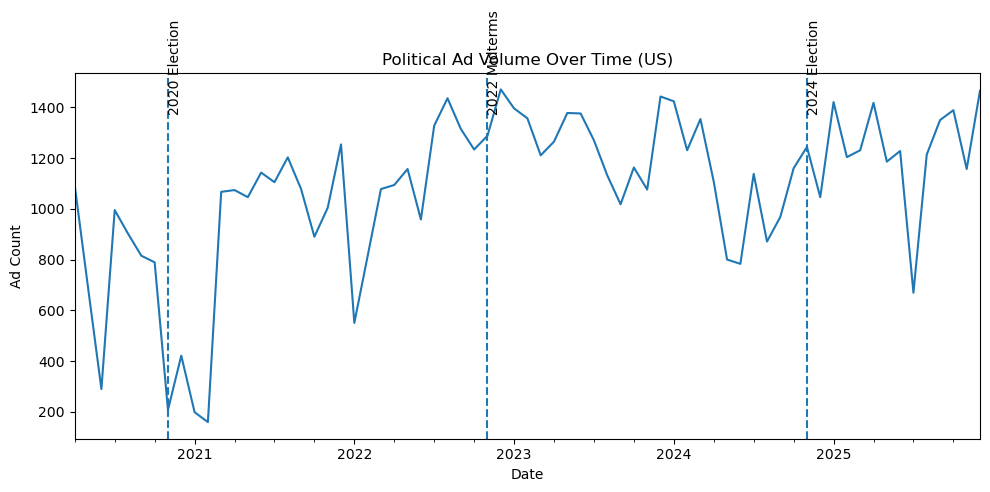

In [ ]:
#1
time_df['year_month'] = time_df['ad_delivery_start_time'].dt.to_period('M')

ads_over_time = (time_df.groupby('year_month').size())

ads_over_time.index = ads_over_time.index.to_timestamp()
important_dates = [
    ('2020-11-03', '2020 Election'),
    ('2022-11-08', '2022 Midterms'),
    ('2024-11-05', '2024 Election')
]

plt.figure(figsize=(10,5))
ads_over_time.plot()

for date, label in important_dates:
    plt.axvline(pd.to_datetime(date), linestyle='--')
    plt.text(pd.to_datetime(date), 
             plt.ylim()[1]*0.9, 
             label, 
             rotation=90)

plt.title("Political Ad Volume Over Time (US)")
plt.ylabel("Ad Count")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

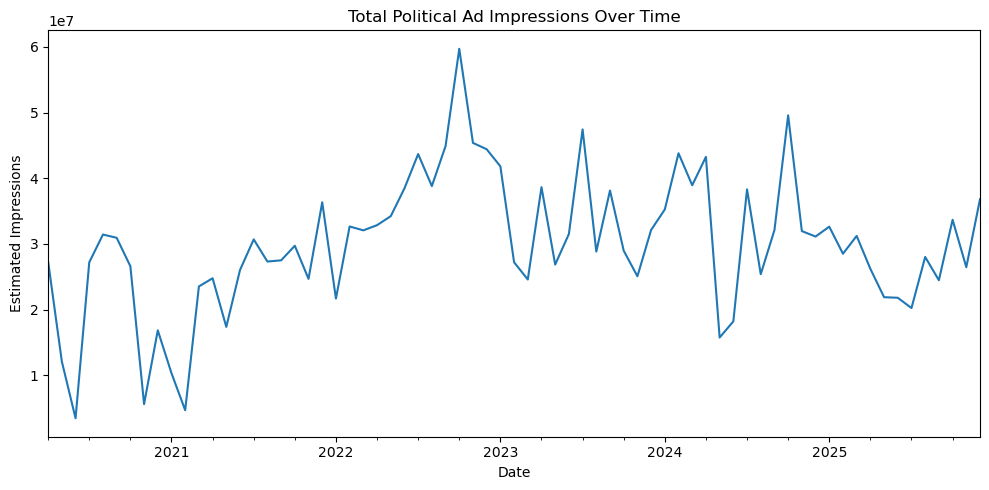

In [ ]:
#2

time_df['impressions_mid'] = (time_df['impressions_lower'] + time_df['impressions_upper']) / 2

impressions_over_time = (time_df.groupby('year_month')['impressions_mid'].sum())

impressions_over_time.index = impressions_over_time.index.to_timestamp()

plt.figure(figsize=(10,5))
impressions_over_time.plot()
plt.title("Total Political Ad Impressions Over Time")
plt.ylabel("Estimated Impressions")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

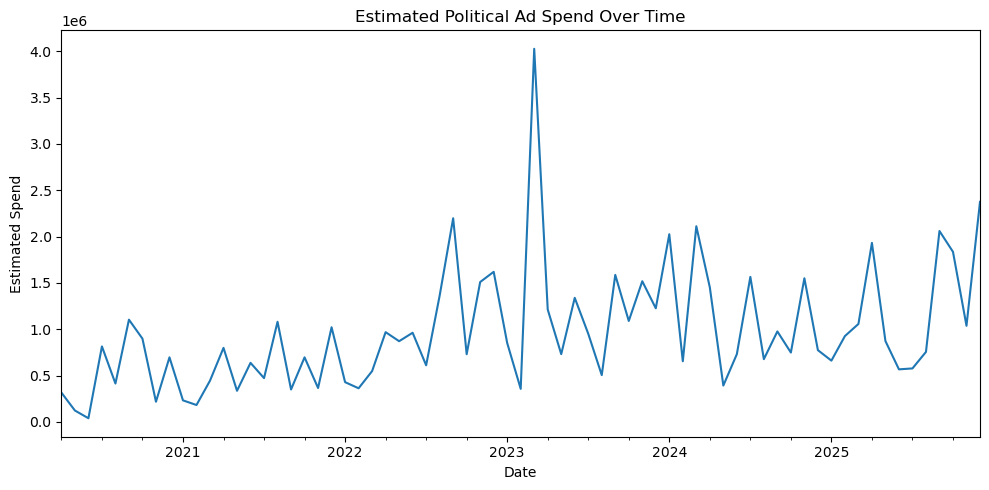

In [ ]:
#3

time_df['spend_mid'] = (time_df['spend_lower'] + time_df['spend_upper']) / 2

spend_over_time = (time_df.groupby('year_month')['spend_mid'].sum())

spend_over_time.index = spend_over_time.index.to_timestamp()

plt.figure(figsize=(10,5))
spend_over_time.plot()
plt.title("Estimated Political Ad Spend Over Time")
plt.ylabel("Estimated Spend")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [68]:
# top spending pages in the spike month of March 2023, which is the month with the highest ad spend in the dataset
df_2023 = time_df[time_df['ad_delivery_start_time'].dt.year == 2023]
top_spike_month = df_2023[df_2023['year_month'] == '2023-03']
top_spike_month.groupby('page_name')['spend_mid'].sum().sort_values(ascending=False).head(10)

page_name
The True Patriots                         949999.5
The Patriot Movement                      849999.5
Walden University                         769996.5
Proud American Patriots                   649999.5
Angela Romero - La Revolución del Amor    252646.5
Metaverse platform - cluster               94999.5
Kristian Thomas for DPRD DKI 2024          94999.5
Everytown for Gun Safety                   89998.0
NEA Today                                  23698.5
SEIU                                       18996.5
Name: spend_mid, dtype: float64

In [69]:
# FINDING BUZZWORDS

In [70]:
df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,45-54/unknown,55-64/female,55-64/male,55-64/unknown,65+/female,65+/male,65+/unknown,Unknown/female,Unknown/male,Unknown/unknown
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.02,0.97,1.22,0.01,0.94,0.80,0.01,0.0,0.0,0.0
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,0.02,2.56,5.44,0.06,3.05,3.22,0.04,0.0,0.0,0.0
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.13,19.85,0.25,20.26,12.40,0.25,0.0,0.0,0.0
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.72,19.94,0.25,18.27,10.68,0.25,0.0,0.0,0.0
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,18.72,21.20,0.28,14.66,10.20,0.22,0.0,0.0,0.0


In [71]:
buzz_df = df.copy()

buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]

buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

demo_cols = [col for col in buzz_df.columns if '/' in col]
demo_cols = [col for col in demo_cols if not col.startswith('Unknown/')]

age_ranges = sorted(set(col.split('/')[0] for col in demo_cols))
genders = sorted(set(col.split('/')[1] for col in demo_cols))

# age totals
for age in age_ranges:
    age_specific_cols = [col for col in demo_cols if col.startswith(age + '/')]
    buzz_df[f'age_{age}_total'] = buzz_df[age_specific_cols].sum(axis=1)

age_total_cols = [f'age_{age}_total' for age in age_ranges]

# gender totals
for gender in genders:
    gender_specific_cols = [col for col in demo_cols if col.endswith('/' + gender)]
    buzz_df[f'gender_{gender}_total'] = buzz_df[gender_specific_cols].sum(axis=1)

gender_total_cols = [f'gender_{gender}_total' for gender in genders]

# original gender + age totals
age_gender_cols = demo_cols.copy()

buzz_df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,age_13-17_total,age_18-24_total,age_25-34_total,age_35-44_total,age_45-54_total,age_55-64_total,age_65+_total,gender_female_total,gender_male_total,gender_unknown_total
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.0,54.17,33.49,5.78,2.62,2.20,1.75,57.79,41.85,0.37
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,0.0,44.80,31.17,5.07,4.60,8.06,6.31,51.23,48.40,0.38
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.35,1.29,5.28,20.94,39.23,32.91,48.63,50.71,0.66
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.34,1.41,6.05,23.08,39.91,29.20,48.17,51.18,0.64
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.35,1.58,7.43,25.35,40.20,25.08,43.19,56.14,0.66


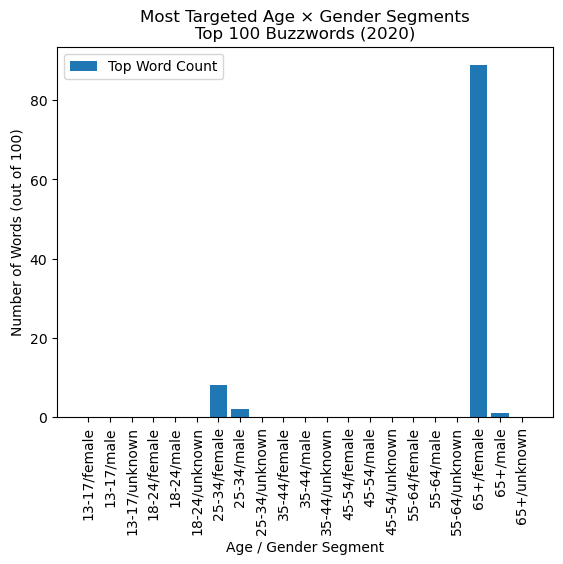

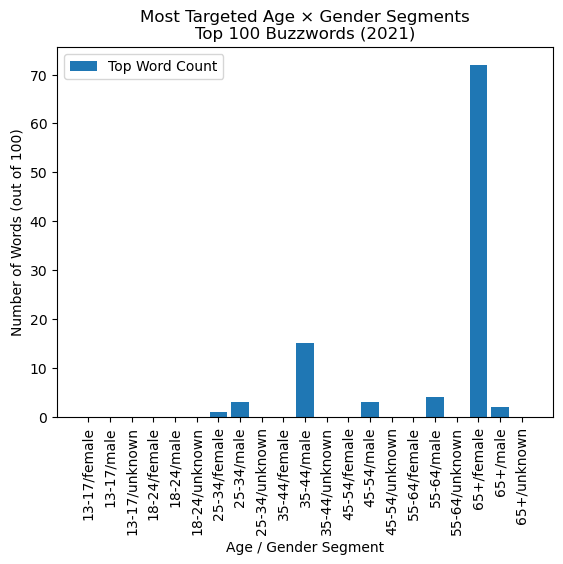

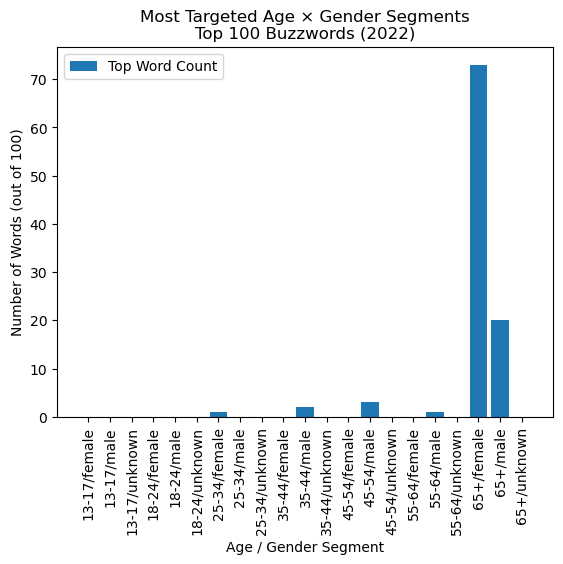

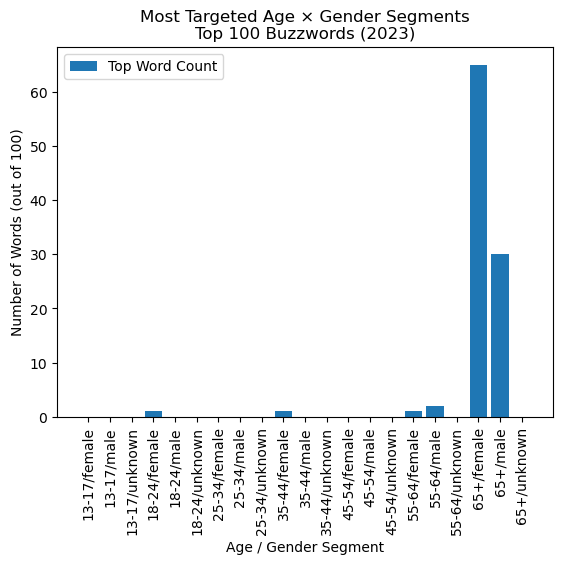

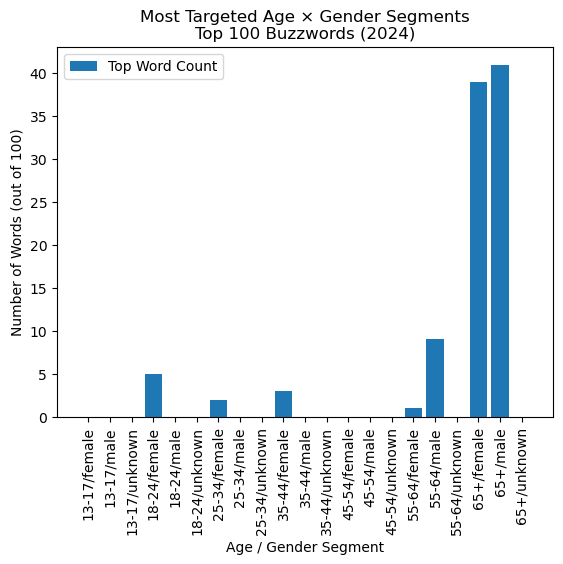

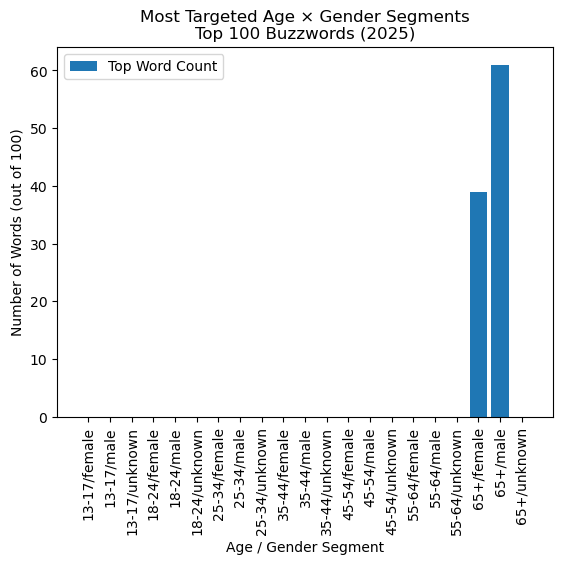

In [ ]:
years = sorted(buzz_df['year'].unique())

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    
    if len(year_df) < 50:
        continue
    
    vectorizer = TfidfVectorizer(stop_words='english',max_features=5000,min_df=5,ngram_range=(1,1))
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    tfidf_means = np.asarray(X.mean(axis=0)).flatten()
    top_indices = tfidf_means.argsort()[-100:][::-1]
    top_words = feature_names[top_indices]
    
    # Age × Gender Targeting Count
    
    segment_counts = {col: 0 for col in age_gender_cols}
    
    for word in top_words:
        
        word_idx = np.where(feature_names == word)[0][0]
        word_mask = X[:, word_idx].toarray().flatten() > 0
        
        if word_mask.sum() == 0:
            continue
        
        subset = year_df.loc[word_mask, age_gender_cols]
        avg_target = subset.mean()
        
        top_segment = avg_target.idxmax()
        segment_counts[top_segment] += 1
    
    plt.figure()
    
    segments = list(segment_counts.keys())
    counts = list(segment_counts.values())
    
    plt.bar(segments, counts, label='Top Word Count')
    
    plt.title(f'Most Targeted Age × Gender Segments\nTop 100 Buzzwords ({year})')
    plt.xlabel('Age / Gender Segment')
    plt.ylabel('Number of Words (out of 100)')
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

buzz_df = buzz_df.copy()
buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]
buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

years = sorted(buzz_df['year'].unique())

top_words_by_year = {}

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    
    if len(year_df) < 50:
        continue
    
    vectorizer = TfidfVectorizer(stop_words='english',max_features=5000,min_df=5,ngram_range=(1,1))
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    tfidf_means = np.asarray(X.mean(axis=0)).flatten()
    top_indices = tfidf_means.argsort()[-100:][::-1]
    top_words = feature_names[top_indices]
    
    top_words_by_year[year] = set(top_words)

In [74]:
for year, words in top_words_by_year.items():
    print(f"\nTop 100 Buzzwords for {year}:\n")
    print(sorted(list(words)))


Top 100 Buzzwords for 2020:

['000', '10', '19', '2020', 'account', 'ad', 'advertising', 'america', 'americans', 'ballot', 'biden', 'black', 'campaign', 'care', 'change', 'click', 'com', 'community', 'congress', 'country', 'covid', 'day', 'democrats', 'disabled', 'disclaimer', 'don', 'donate', 'election', 'ensure', 'fair', 'families', 'fight', 'following', 'free', 'georgia', 'great', 'help', 'hey', 'https', 'information', 'joe', 'join', 'just', 'know', 'later', 'learn', 'let', 'like', 'mail', 'make', 'national', 'need', 'new', 'news', 'november', 'office', 'open', 'org', 'page', 'people', 'petition', 'political', 'power', 'president', 'protect', 'public', 'quiz', 'ran', 'register', 'request', 'required', 'right', 'run', 'safe', 'save', 'sees', 'senate', 'share', 'shirt', 'sign', 'stand', 'standards', 'state', 'states', 'stop', 'support', 'sure', 'tax', 'think', 'time', 'today', 'trump', 'use', 'vote', 'voter', 'voting', 'want', 'world', 'www', 'yes']

Top 100 Buzzwords for 2021:

['20

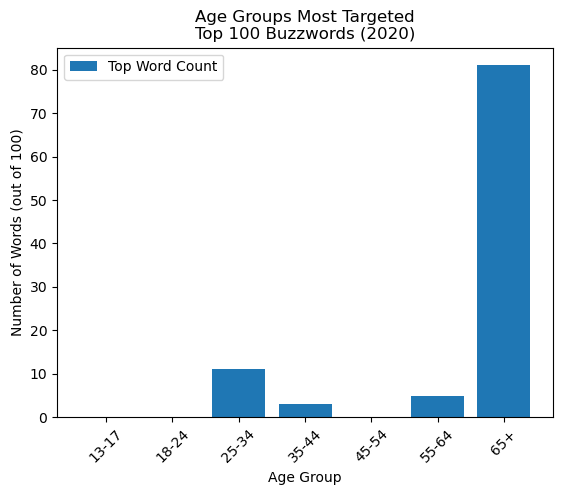

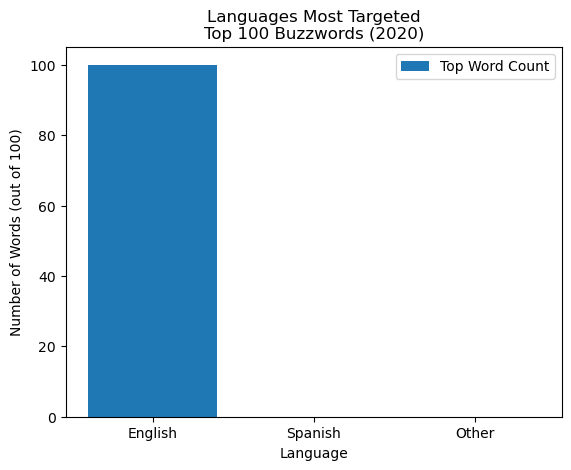

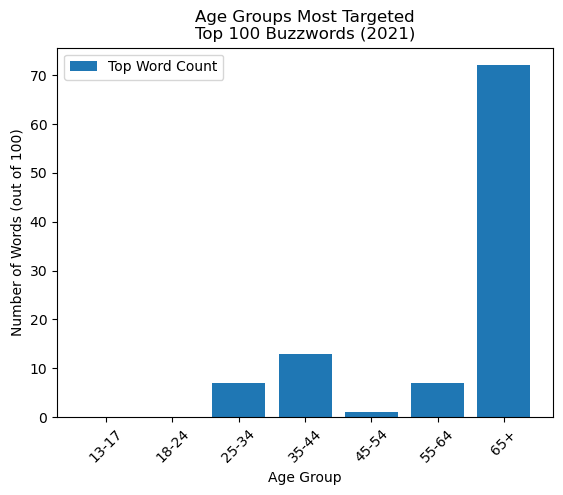

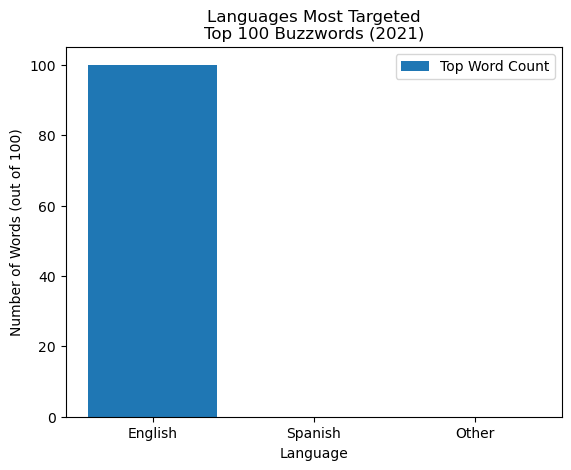

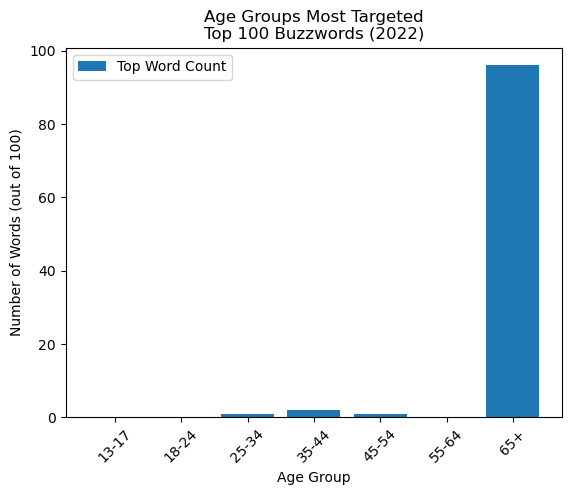

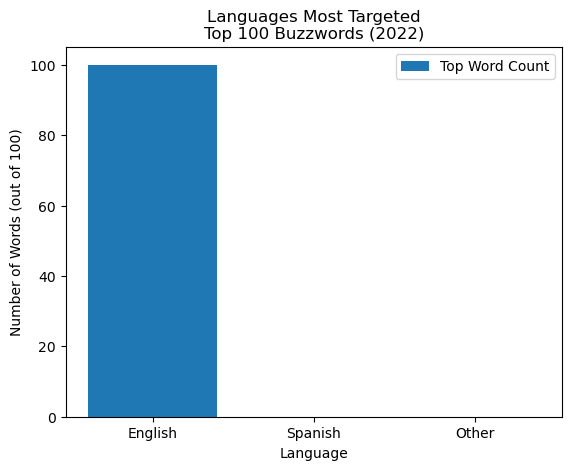

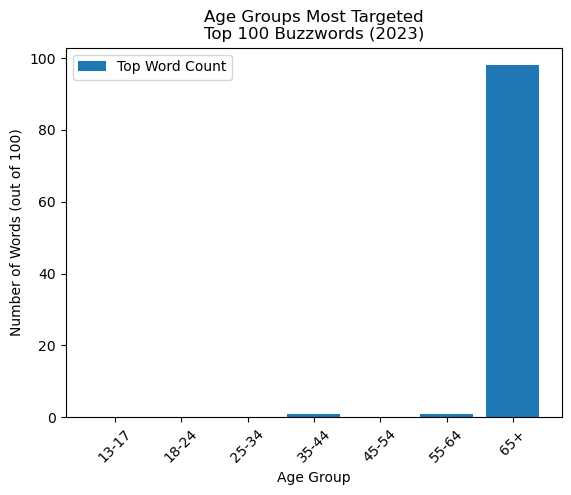

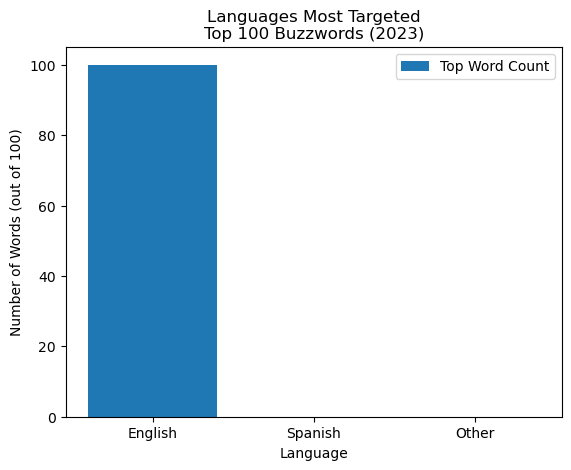

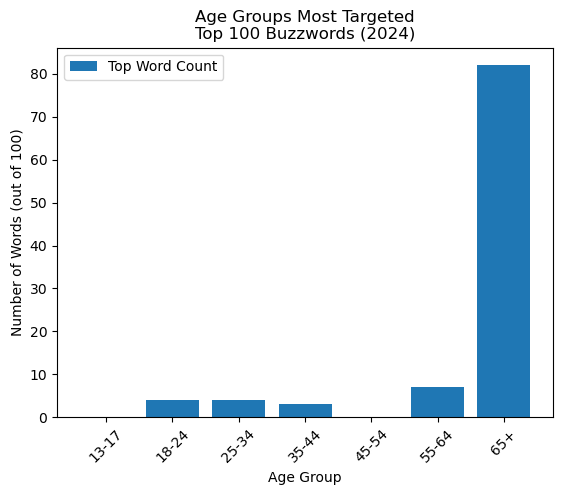

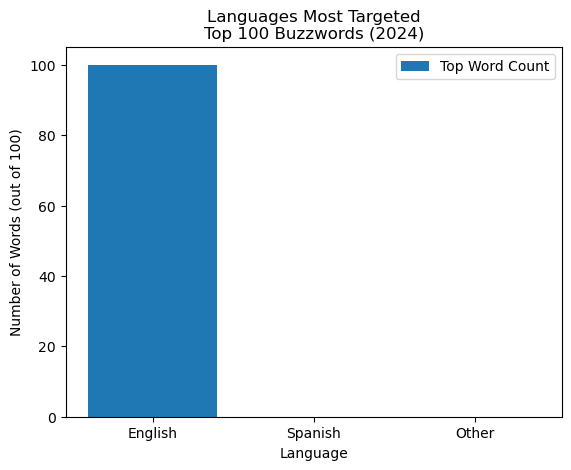

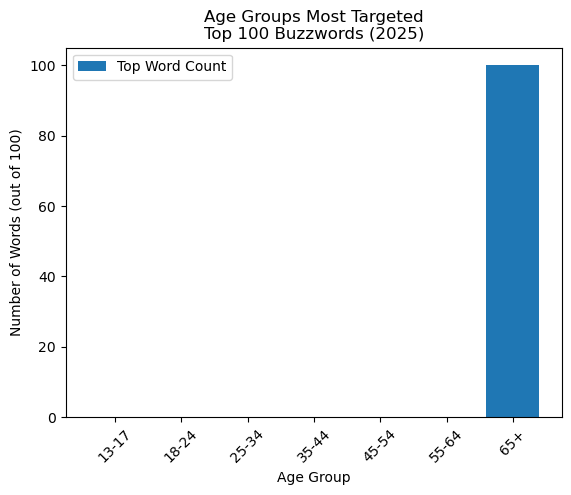

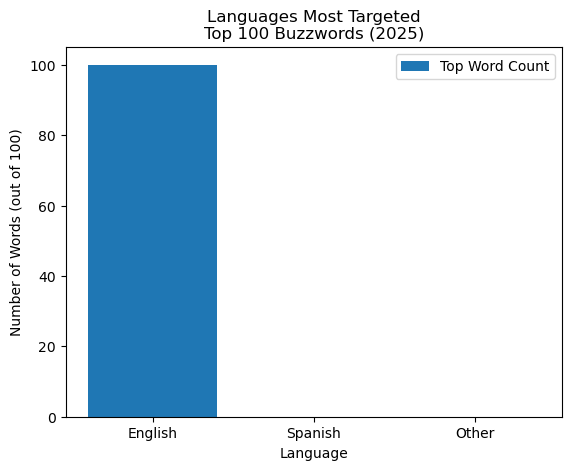

In [ ]:
age_cols = [col for col in buzz_df.columns if col.startswith('age_') and col.endswith('_total')]
language_cols = ['language_en', 'language_es', 'language_other']

years = sorted(top_words_by_year.keys())

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    top_words = top_words_by_year[year]
    
    # Recompute TFIDF for mask indexing
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, min_df=5)
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    #age targeting counts
    
    age_counts = {col.replace('age_','').replace('_total',''): 0 for col in age_cols}
    
    language_counts = {'English':0, 'Spanish':0, 'Other':0}
    
    for word in top_words:
        
        if word not in feature_names:
            continue
        
        word_idx = np.where(feature_names == word)[0][0]
        word_mask = X[:, word_idx].toarray().flatten() > 0
        
        if word_mask.sum() == 0:
            continue
        
        subset = year_df.loc[word_mask]
        
        # age
        avg_age = subset[age_cols].mean()
        top_age = avg_age.idxmax()
        top_age_clean = top_age.replace('age_','').replace('_total','')
        age_counts[top_age_clean] += 1
        
        # language
        avg_lang = subset[language_cols].mean()
        top_lang = avg_lang.idxmax()
        
        if top_lang == 'language_en':
            language_counts['English'] += 1
        elif top_lang == 'language_es':
            language_counts['Spanish'] += 1
        else:
            language_counts['Other'] += 1
    
# plot age targeting result
    
    plt.figure()
    plt.bar(age_counts.keys(), age_counts.values(), label='Top Word Count')
    plt.title(f'Age Groups Most Targeted\nTop 100 Buzzwords ({year})')
    plt.xlabel('Age Group')
    plt.ylabel('Number of Words (out of 100)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()
    
#plot language result
    
    plt.figure()
    plt.bar(language_counts.keys(), language_counts.values(), label='Top Word Count')
    plt.title(f'Languages Most Targeted\nTop 100 Buzzwords ({year})')
    plt.xlabel('Language')
    plt.ylabel('Number of Words (out of 100)')
    plt.legend()
    plt.show()

In [ ]:
years_list = list(top_words_by_year.keys())

overlap_matrix = pd.DataFrame(index=years_list,columns=years_list)

for y1 in years_list:
    for y2 in years_list:
        intersection = top_words_by_year[y1].intersection(top_words_by_year[y2])
        overlap_matrix.loc[y1, y2] = len(intersection)

overlap_matrix = overlap_matrix.astype(int)

print("\nOverlap Matrix (Raw Counts):\n")
print(overlap_matrix)


Overlap Matrix (Raw Counts):

      2020  2021  2022  2023  2024  2025
2020   100    60    65    62    50    51
2021    60   100    79    66    53    54
2022    65    79   100    73    59    60
2023    62    66    73   100    61    61
2024    50    53    59    61   100    67
2025    51    54    60    61    67   100


In [77]:
percent_overlap_matrix = overlap_matrix / 100 * 100  # since top 100
print("\nOverlap Matrix (Percentage):\n")
print(percent_overlap_matrix)


Overlap Matrix (Percentage):

       2020   2021   2022   2023   2024   2025
2020  100.0   60.0   65.0   62.0   50.0   51.0
2021   60.0  100.0   79.0   66.0   53.0   54.0
2022   65.0   79.0  100.0   73.0   59.0   60.0
2023   62.0   66.0   73.0  100.0   61.0   61.0
2024   50.0   53.0   59.0   61.0  100.0   67.0
2025   51.0   54.0   60.0   61.0   67.0  100.0


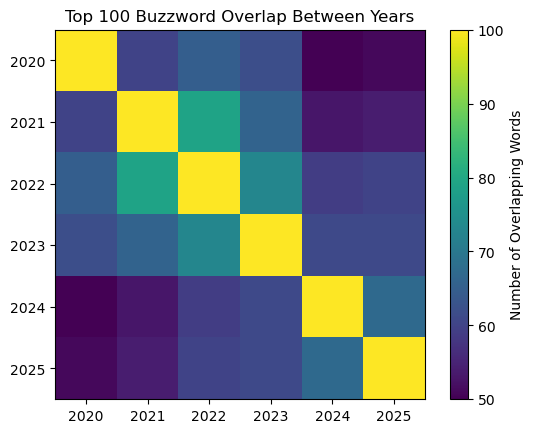

In [78]:
plt.figure()

plt.imshow(overlap_matrix.values)
plt.xticks(range(len(years_list)), years_list)
plt.yticks(range(len(years_list)), years_list)
plt.title("Top 100 Buzzword Overlap Between Years")
plt.colorbar(label='Number of Overlapping Words')

plt.show()

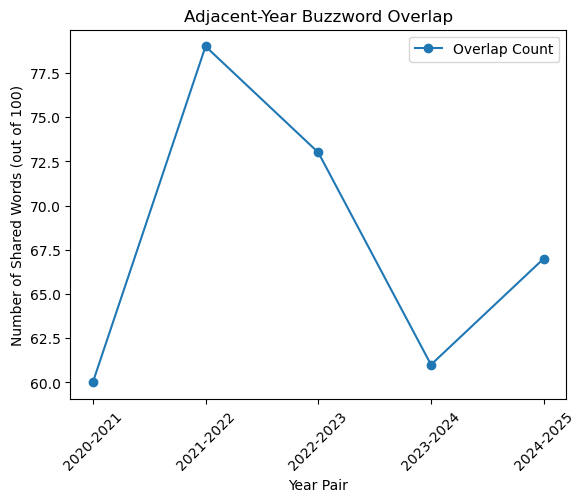

In [ ]:
adjacent_overlap = {}

for i in range(len(years_list)-1):
    y1 = years_list[i]
    y2 = years_list[i+1]
    
    overlap = len(top_words_by_year[y1] & top_words_by_year[y2])
    adjacent_overlap[f"{y1}-{y2}"] = overlap

plt.figure()
plt.plot(list(adjacent_overlap.keys()),list(adjacent_overlap.values()), marker='o', label='Overlap Count')

plt.title('Adjacent-Year Buzzword Overlap')
plt.xlabel('Year Pair')
plt.ylabel('Number of Shared Words (out of 100)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

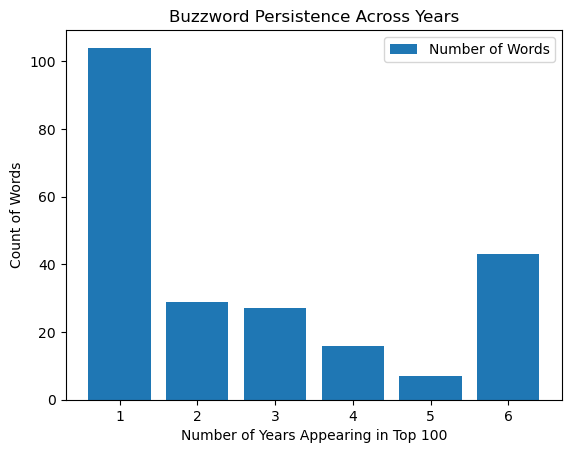

In [ ]:
from collections import Counter

all_words = []

for words in top_words_by_year.values():
    all_words.extend(list(words))

word_counts = Counter(all_words)

survival_counts = Counter(word_counts.values())

plt.figure()
plt.bar(survival_counts.keys(), survival_counts.values(), label='Number of Words')

plt.title('Buzzword Persistence Across Years')
plt.xlabel('Number of Years Appearing in Top 100')
plt.ylabel('Count of Words')
plt.legend()
plt.show()

In [81]:
# FREQUENCY OF ADS BY LANGUAGE CATEGORY

In [82]:
df[['language_en','language_es','language_other']].head()

,language_en,language_es,language_other
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [ ]:
language_counts = {'English': df['language_en'].sum(), 'Spanish': df['language_es'].sum(), 'Other': df['language_other'].sum()}

language_counts

{'English': np.int64(68214), 'Spanish': np.int64(1631), 'Other': np.int64(680)}

In [84]:
df[['language_en','language_es','language_other']].sum(axis=1).value_counts()

1    70471
0     3788
2       24
3        2
Name: count, dtype: int64

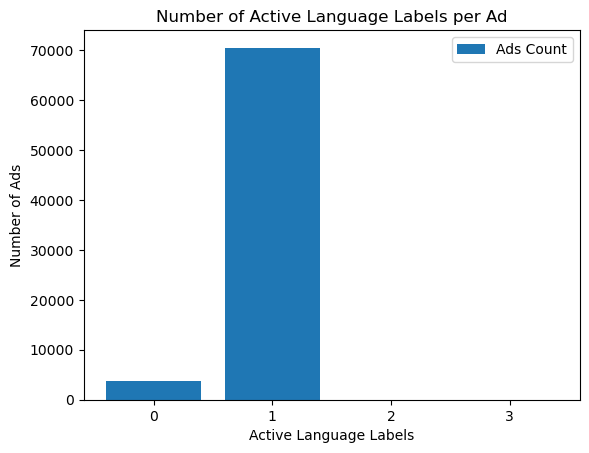

In [85]:
# number of active language labels per ad
lang_cols = ['language_en', 'language_es', 'language_other']
row_sums = df[lang_cols].sum(axis=1)
consistency_counts = row_sums.value_counts().sort_index()

plt.figure()
plt.bar(consistency_counts.index.astype(str), consistency_counts.values, label='Ads Count')
plt.title('Number of Active Language Labels per Ad')
plt.xlabel('Active Language Labels')
plt.ylabel('Number of Ads')
plt.legend()
plt.show()

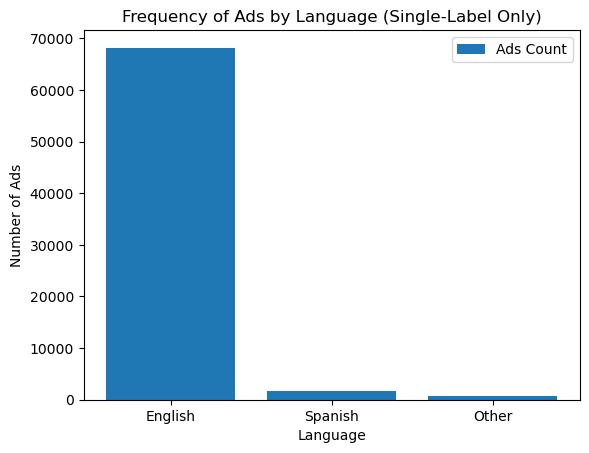

In [88]:
# language vs. frequency (single-label only)
clean_df = df[row_sums == 1]
clean_counts = clean_df[lang_cols].sum()

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], clean_counts.values, label='Ads Count')
plt.title('Frequency of Ads by Language (Single-Label Only)')
plt.xlabel('Language')
plt.ylabel('Number of Ads')
plt.legend()
plt.show()

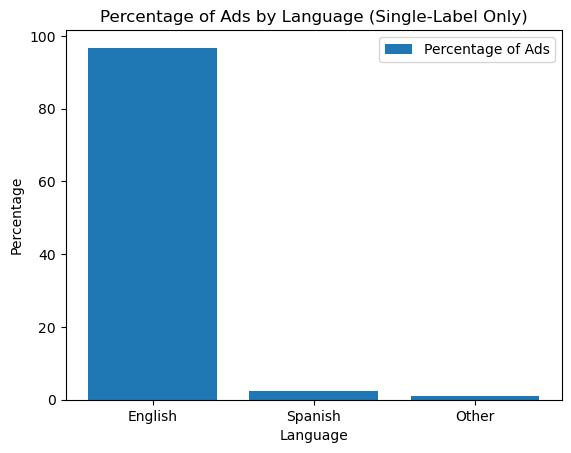

In [89]:
# language vs. percentage of ads
clean_percent = clean_counts / clean_counts.sum() * 100

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], clean_percent.values, label='Percentage of Ads')
plt.title('Percentage of Ads by Language (Single-Label Only)')
plt.xlabel('Language')
plt.ylabel('Percentage')
plt.legend()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_32120\1871219516.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['spend_avg'] = (clean_df['spend_lower'] + clean_df['spend_upper']) / 2


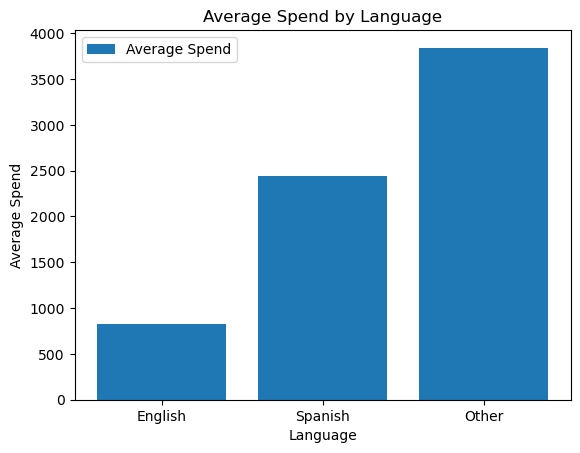

In [ ]:
# language vs. average spend
clean_df['spend_avg'] = (clean_df['spend_lower'] + clean_df['spend_upper']) / 2

avg_spend = [clean_df[clean_df['language_en']]['spend_avg'].mean(), clean_df[clean_df['language_es']]['spend_avg'].mean(),
    clean_df[clean_df['language_other']]['spend_avg'].mean()]

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], avg_spend, label='Average Spend')
plt.title('Average Spend by Language')
plt.xlabel('Language')
plt.ylabel('Average Spend')
plt.legend()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_32120\3683665048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['impressions_avg'] = (clean_df['impressions_lower'] + clean_df['impressions_upper']) / 2


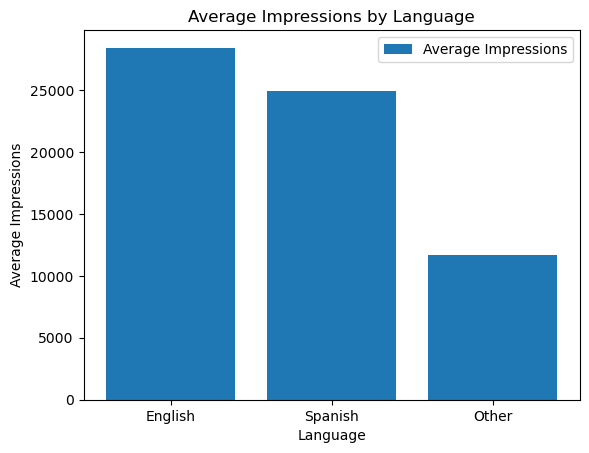

In [ ]:
# language vs. average impressions
clean_df['impressions_avg'] = (clean_df['impressions_lower'] + clean_df['impressions_upper']) / 2

avg_impressions = [clean_df[clean_df['language_en']]['impressions_avg'].mean(), clean_df[clean_df['language_es']]['impressions_avg'].mean(),
    clean_df[clean_df['language_other']]['impressions_avg'].mean()]

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], avg_impressions, label='Average Impressions')
plt.title('Average Impressions by Language')
plt.xlabel('Language')
plt.ylabel('Average Impressions')
plt.legend()
plt.show()

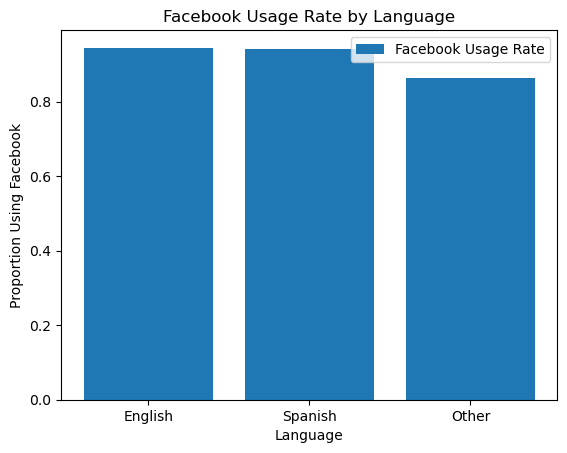

In [ ]:
# language vs. platform usage (Facebook vs Instagram)
platform_usage = [clean_df[clean_df['language_en']]['platform_fb'].mean(), clean_df[clean_df['language_es']]['platform_fb'].mean(),
    clean_df[clean_df['language_other']]['platform_fb'].mean()]

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], platform_usage, label='Facebook Usage Rate')
plt.title('Facebook Usage Rate by Language')
plt.xlabel('Language')
plt.ylabel('Proportion Using Facebook')
plt.legend()
plt.show()

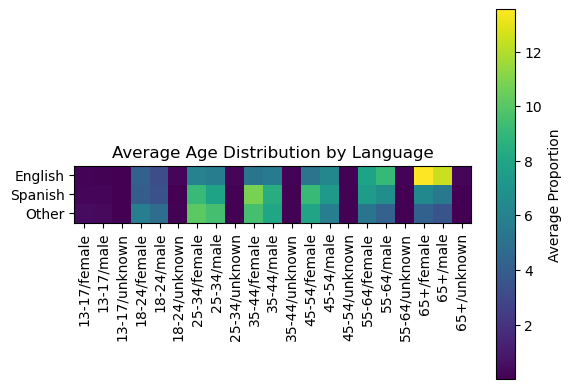

In [93]:
# language vs. age distribution
age_cols = [col for col in df.columns if '/' in col and col.split('/')[0] != 'Unknown']

age_distribution = []
for lang in lang_cols:
    subset = clean_df[clean_df[lang]]
    age_distribution.append(subset[age_cols].mean().values)

age_distribution = np.array(age_distribution)

plt.figure()
plt.imshow(age_distribution)
plt.xticks(range(len(age_cols)), age_cols, rotation=90)
plt.yticks(range(3), ['English', 'Spanish', 'Other'])
plt.title('Average Age Distribution by Language')
plt.colorbar(label='Average Proportion')
plt.show()

In [94]:
#INSIGHTS

In [ ]:
df["ad_creation_time"] = pd.to_datetime(df["ad_creation_time"], errors="coerce")
df["ad_delivery_start_time"] = pd.to_datetime(df["ad_delivery_start_time"], errors="coerce")

# Midpoints for bounded metrics
df["impressions_mid"] = (df["impressions_lower"] + df["impressions_upper"]) / 2
df["spend_mid"] = (df["spend_lower"] + df["spend_upper"]) / 2

# Delivery lag
df["delivery_lag_days"] = (
    df["ad_delivery_start_time"] - df["ad_creation_time"]
).dt.days

# Month for temporal analysis
df["delivery_month"] = df["ad_delivery_start_time"].dt.to_period("M").astype(str)

# Demographic columns
demo_cols = ["13-17/female","13-17/male","13-17/unknown", "18-24/female","18-24/male","18-24/unknown",
    "25-34/female","25-34/male","25-34/unknown", "35-44/female","35-44/male","35-44/unknown",
    "45-54/female","45-54/male","45-54/unknown", "55-64/female","55-64/male","55-64/unknown",
    "65+/female","65+/male","65+/unknown", "Unknown/female","Unknown/male","Unknown/unknown"]

df["demo_sum"] = df[demo_cols].sum(axis=1)
df["demo_complete"] = np.isclose(df["demo_sum"], 100, atol=0.5)

print(df[["impressions_mid", "spend_mid", "delivery_lag_days", "demo_sum", "demo_complete"]].head())

   impressions_mid  spend_mid  delivery_lag_days  demo_sum  demo_complete
0          64999.5      149.5                  0    100.01           True
1          22499.5       49.5                  0    100.01           True
2          64999.5      749.5                  0    100.00           True
3          64999.5      749.5                  0     99.99           True
4          74999.5      749.5                  0     99.99           True


In [ ]:
# Missingness table
missing = pd.DataFrame({"missing_count": df.isna().sum(), "missing_pct": df.isna().mean() * 100}).sort_values("missing_pct", ascending=False)

missing.head(20)

,missing_count,missing_pct
ad_creative_link_descriptions,23986,32.289157
bylines,13717,18.465370
ad_creative_link_titles,9375,12.620314
ad_creative_link_captions,7347,9.890287
ad_creative_bodies,2420,3.257724
impressions_upper,810,1.090395
impressions_mid,810,1.090395
page_name,249,0.335196
spend_upper,4,0.005385
spend_mid,4,0.005385


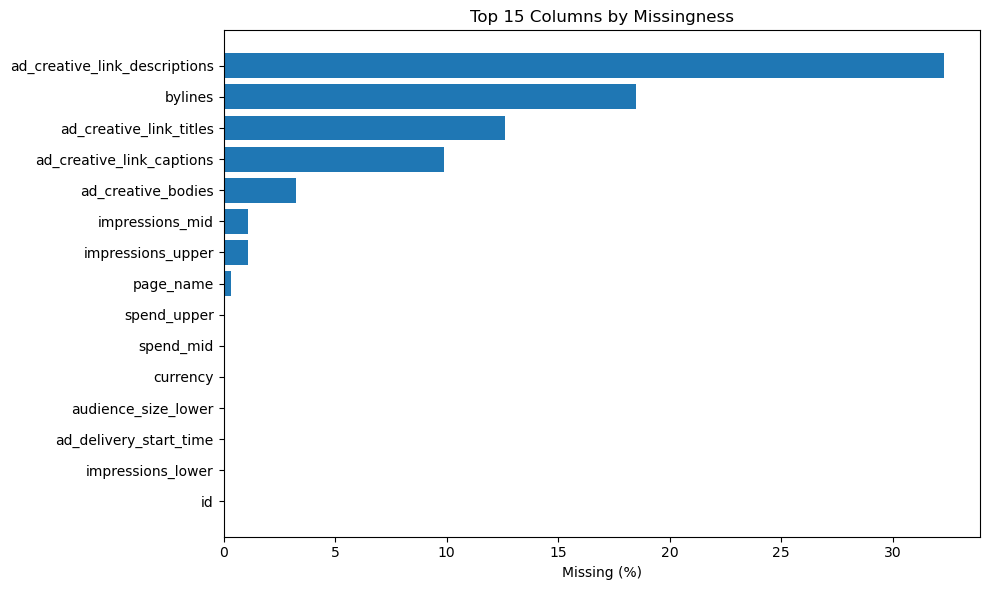

In [97]:
# Missingness plot
top_missing = missing.head(15).sort_values("missing_pct")

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index, top_missing["missing_pct"])
plt.xlabel("Missing (%)")
plt.title("Top 15 Columns by Missingness")
plt.tight_layout()
plt.show()

In [98]:
# Demographic completeness check

demo_quality = pd.DataFrame({
    "count": [len(df), df["demo_complete"].sum(), (~df["demo_complete"]).sum()],
    "pct": [100, df["demo_complete"].mean() * 100, (~df["demo_complete"]).mean() * 100]
    }, index=["all_rows", "demo_complete", "demo_incomplete"])

demo_quality

,count,pct
all_rows,74285,100.000000
demo_complete,63292,85.201588
demo_incomplete,10993,14.798412


In [ ]:
# Are incomplete demographic rows mostly zero-delivery rows?
incomplete = df.loc[~df["demo_complete"]].copy()

summary_incomplete = pd.Series({"rows": len(incomplete), "pct_impressions_lower_zero": (incomplete["impressions_lower"] == 0).mean() * 100,
    "pct_spend_lower_zero": (incomplete["spend_lower"] == 0).mean() * 100, "pct_impressions_mid_zero": (incomplete["impressions_mid"] == 0).mean() * 100,
    "pct_spend_mid_zero": (incomplete["spend_mid"] == 0).mean() * 100,})

summary_incomplete

rows                          10993.000000
pct_impressions_lower_zero       98.617302
pct_spend_lower_zero             98.207951
pct_impressions_mid_zero          0.000000
pct_spend_mid_zero                0.000000
dtype: float64

In [ ]:
# Data quality checks
quality_checks = pd.Series({
    "audience_size_lower_nunique": df["audience_size_lower"].nunique(),
    "audience_size_lower_mode": df["audience_size_lower"].mode().iloc[0],
    "audience_size_lower_mode_pct": (df["audience_size_lower"] == df["audience_size_lower"].mode().iloc[0]).mean() * 100,
    "impressions_lower_at_1m_pct": (df["impressions_lower"] == 1_000_000).mean() * 100,
    "spend_lower_at_1m_pct": (df["spend_lower"] == 1_000_000).mean() * 100,})

quality_checks

audience_size_lower_nunique     2.000000e+00
audience_size_lower_mode        1.000001e+06
audience_size_lower_mode_pct    9.999865e+01
impressions_lower_at_1m_pct     1.090395e+00
spend_lower_at_1m_pct           5.384667e-03
dtype: float64

In [101]:
# Distribution summaries

dist_summary = df[["impressions_mid", "spend_mid", "delivery_lag_days"]].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
dist_summary

,count,mean,std,min,50%,75%,90%,95%,99%,max
impressions_mid,73475.0,28040.847397,91628.212863,499.5,2499.5,12499.5,54999.5,137499.5,549999.5,949999.5
spend_mid,74281.0,904.004517,11426.216535,49.5,49.5,149.5,749.5,2249.5,12499.5,949999.5
delivery_lag_days,74285.0,0.492643,3.551424,-40.0,0.0,0.0,1.0,2.0,10.0,204.0


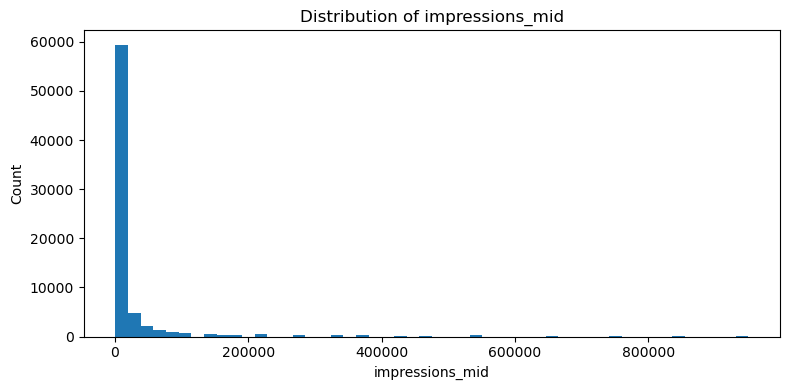

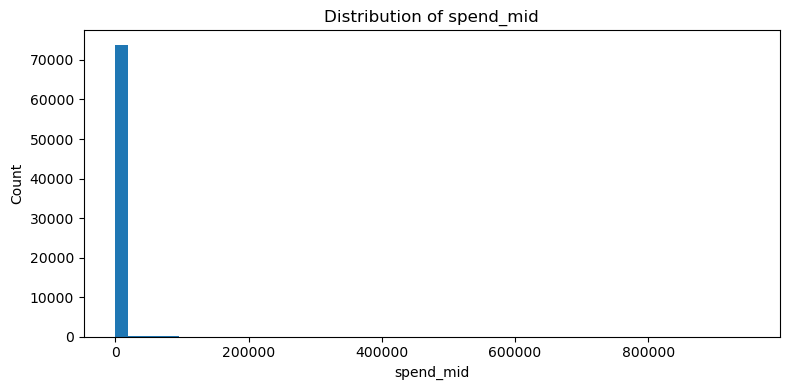

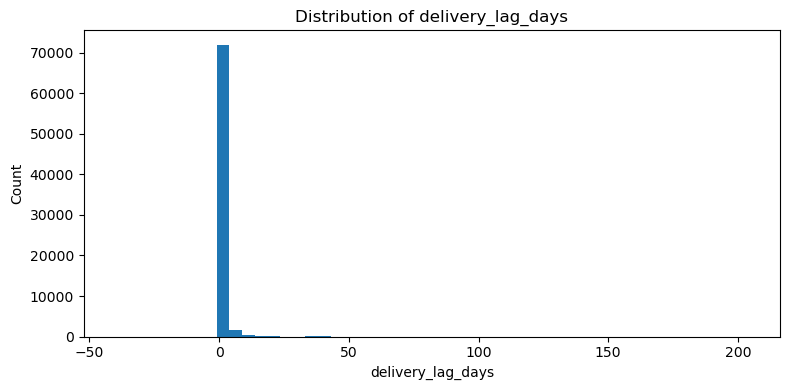

In [102]:
# Histograms
for col in ["impressions_mid", "spend_mid", "delivery_lag_days"]:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

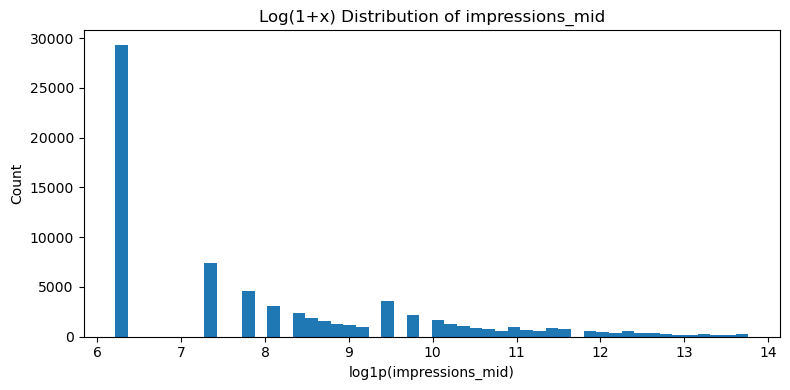

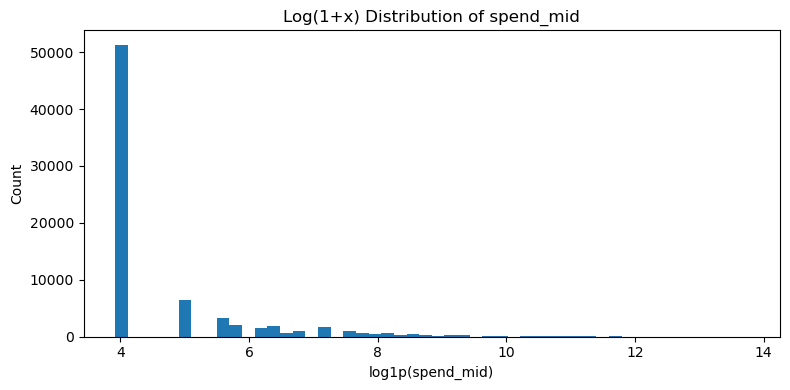

In [103]:
# Log-scale histograms for skewed variables
for col in ["impressions_mid", "spend_mid"]:
    plt.figure(figsize=(8, 4))
    plt.hist(np.log1p(df[col].dropna()), bins=50)
    plt.title(f"Log(1+x) Distribution of {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [ ]:
# Outlier detection (IQR)
def iqr_outlier_summary(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flags = (series < lower) | (series > upper)
    return pd.Series({"q1": q1, "q3": q3, "iqr": iqr, "lower_bound": lower,"upper_bound": upper, "outlier_count": flags.sum(), "outlier_pct": flags.mean() * 100})

outlier_table = pd.DataFrame({"impressions_mid": iqr_outlier_summary(df["impressions_mid"]), "spend_mid": iqr_outlier_summary(df["spend_mid"]),
                              "delivery_lag_days": iqr_outlier_summary(df["delivery_lag_days"]),}).T

outlier_table

,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
impressions_mid,499.5,12499.5,12000.0,-17500.5,30499.5,11141.0,14.997644
spend_mid,49.5,149.5,100.0,-100.5,299.5,13335.0,17.951134
delivery_lag_days,0.0,0.0,0.0,0.0,0.0,8683.0,11.688766


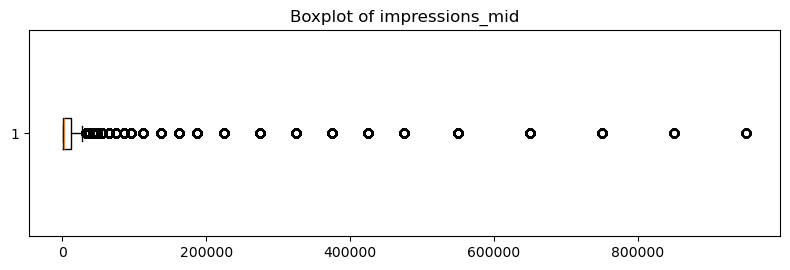

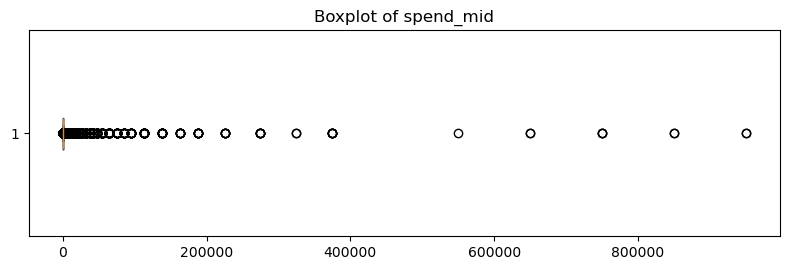

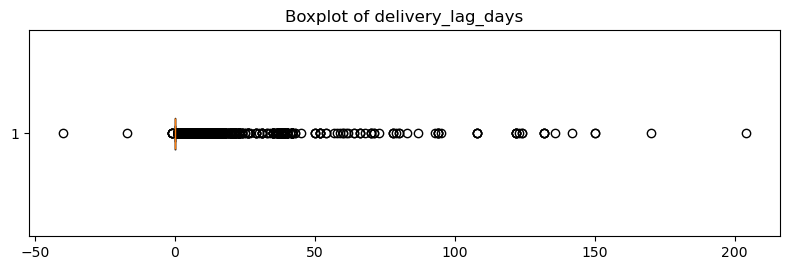

In [105]:
# Boxplots
for col in ["impressions_mid", "spend_mid", "delivery_lag_days"]:
    plt.figure(figsize=(8, 2.8))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Correlations (numeric relationships)

num_cols = [ "audience_size_lower", "impressions_lower", "impressions_upper", "impressions_mid", "spend_lower", 
    "spend_upper", "spend_mid", "delivery_lag_days", "language_en", "language_es", "language_other",
    "platform_fb", "platform_ig", "platform_other" ]

pearson_corr = df[num_cols].corr(method="pearson")
spearman_corr = df[num_cols].corr(method="spearman")

print("Pearson correlation with impressions_mid")
display(pearson_corr["impressions_mid"].sort_values(ascending=False))

print("\nSpearman correlation with impressions_mid")
display(spearman_corr["impressions_mid"].sort_values(ascending=False))

print("\nPearson correlation with spend_mid")
display(pearson_corr["spend_mid"].sort_values(ascending=False))

print("\nSpearman correlation with spend_mid")
display(spearman_corr["spend_mid"].sort_values(ascending=False))

Pearson correlation with impressions_mid


impressions_mid        1.000000
impressions_upper      0.999874
impressions_lower      0.999833
spend_upper            0.106614
spend_mid              0.103553
spend_lower            0.080795
delivery_lag_days      0.044168
platform_ig            0.028686
language_en            0.014287
audience_size_lower    0.001109
platform_fb           -0.002315
language_es           -0.004021
language_other        -0.017308
platform_other        -0.079895
Name: impressions_mid, dtype: float64


Spearman correlation with impressions_mid


impressions_lower      1.000000
impressions_upper      1.000000
impressions_mid        1.000000
spend_lower            0.750874
spend_upper            0.750836
spend_mid              0.750836
delivery_lag_days      0.042750
language_en            0.042410
platform_ig            0.005632
audience_size_lower    0.003972
language_es           -0.001381
platform_fb           -0.007225
language_other        -0.034290
platform_other        -0.235022
Name: impressions_mid, dtype: float64


Pearson correlation with spend_mid


spend_mid              1.000000
spend_upper            0.999848
spend_lower            0.999799
impressions_lower      0.250473
impressions_upper      0.103880
impressions_mid        0.103553
language_other         0.024399
language_es            0.019815
platform_ig            0.011603
delivery_lag_days      0.007424
platform_fb            0.000535
audience_size_lower    0.000274
platform_other        -0.005843
language_en           -0.023871
Name: spend_mid, dtype: float64


Spearman correlation with spend_mid


spend_lower            1.000000
spend_upper            1.000000
spend_mid              1.000000
impressions_lower      0.760240
impressions_upper      0.750836
impressions_mid        0.750836
delivery_lag_days      0.075613
platform_ig            0.048435
platform_fb            0.023918
language_en            0.018901
audience_size_lower    0.002405
language_es            0.000207
language_other        -0.021243
platform_other        -0.147982
Name: spend_mid, dtype: float64

In [ ]:
# Key pair: spend vs impressions
pair_corr = pd.Series({"pearson_spend_vs_impressions": df["spend_mid"].corr(df["impressions_mid"], method="pearson"),
    "spearman_spend_vs_impressions": df["spend_mid"].corr(df["impressions_mid"], method="spearman"),
    "pearson_lag_vs_impressions": df["delivery_lag_days"].corr(df["impressions_mid"], method="pearson"),
    "pearson_lag_vs_spend": df["delivery_lag_days"].corr(df["spend_mid"], method="pearson"),})
pair_corr

pearson_spend_vs_impressions     0.103553
spearman_spend_vs_impressions    0.750836
pearson_lag_vs_impressions       0.044168
pearson_lag_vs_spend             0.007424
dtype: float64

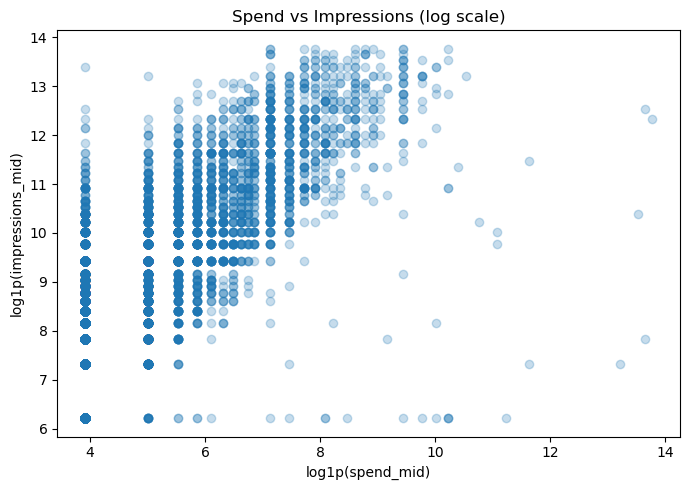

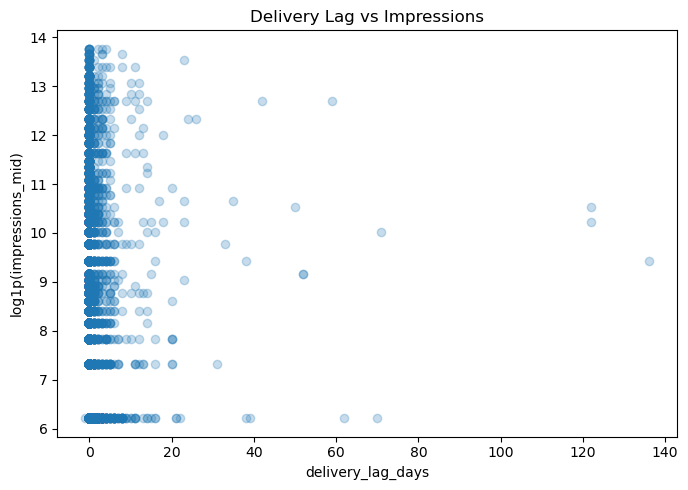

In [108]:
# Scatterplots on log scale
sample = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(np.log1p(sample["spend_mid"]), np.log1p(sample["impressions_mid"]), alpha=0.25)
plt.xlabel("log1p(spend_mid)")
plt.ylabel("log1p(impressions_mid)")
plt.title("Spend vs Impressions (log scale)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(sample["delivery_lag_days"], np.log1p(sample["impressions_mid"]), alpha=0.25)
plt.xlabel("delivery_lag_days")
plt.ylabel("log1p(impressions_mid)")
plt.title("Delivery Lag vs Impressions")
plt.tight_layout()
plt.show()

In [ ]:
# Platform and language comparisons
platform_summary = pd.DataFrame({ "fb_true": df.loc[df["platform_fb"] == 1, ["spend_mid", "impressions_mid"]].mean(),
    "fb_false": df.loc[df["platform_fb"] == 0, ["spend_mid", "impressions_mid"]].mean(),
    "ig_true": df.loc[df["platform_ig"] == 1, ["spend_mid", "impressions_mid"]].mean(),
    "ig_false": df.loc[df["platform_ig"] == 0, ["spend_mid", "impressions_mid"]].mean(),
    "other_true": df.loc[df["platform_other"] == 1, ["spend_mid", "impressions_mid"]].mean(),
    "other_false": df.loc[df["platform_other"] == 0, ["spend_mid", "impressions_mid"]].mean(),}).T

platform_summary

,spend_mid,impressions_mid
fb_true,905.510195,27988.719224
fb_false,879.194118,28903.920550
ig_true,977.587414,29503.858600
ig_false,665.148222,23318.534467
other_true,725.045394,8497.674981
other_false,928.914155,30783.030434


In [ ]:
platform_coverage = pd.Series({"platform_fb_pct": df["platform_fb"].mean() * 100,
    "platform_ig_pct": df["platform_ig"].mean() * 100,
    "platform_other_pct": df["platform_other"].mean() * 100,
    "language_en_pct": df["language_en"].mean() * 100,
    "language_es_pct": df["language_es"].mean() * 100,
    "language_other_pct": df["language_other"].mean() * 100,})

platform_coverage

platform_fb_pct       94.278791
platform_ig_pct       76.450158
platform_other_pct    12.223194
language_en_pct       91.827421
language_es_pct        2.195598
language_other_pct     0.915393
dtype: float64

In [ ]:
language_summary = pd.DataFrame({
    "en_true": df.loc[df["language_en"] == 1, ["spend_mid", "impressions_mid"]].mean(),
    "es_true": df.loc[df["language_es"] == 1, ["spend_mid", "impressions_mid"]].mean(),
    "other_true": df.loc[df["language_other"] == 1, ["spend_mid", "impressions_mid"]].mean(),}).T

language_summary

,spend_mid,impressions_mid
en_true,822.655410,28431.28753
es_true,2415.103924,25580.19522
other_true,3808.718289,11607.90708


In [112]:
# Demographic patterns

demo_complete_df = df.loc[df["demo_complete"]].copy()

demo_means = demo_complete_df[demo_cols].mean().sort_values(ascending=False)
demo_means.head(15)

65+/female       15.496442
65+/male         14.357725
55-64/male       10.516233
55-64/female      9.103176
45-54/male        7.318625
25-34/female      7.106896
25-34/male        6.815811
35-44/male        6.670447
35-44/female      6.288243
45-54/female      6.178480
18-24/female      4.948253
18-24/male        3.812109
65+/unknown       0.237659
25-34/unknown     0.216031
18-24/unknown     0.201564
dtype: float64

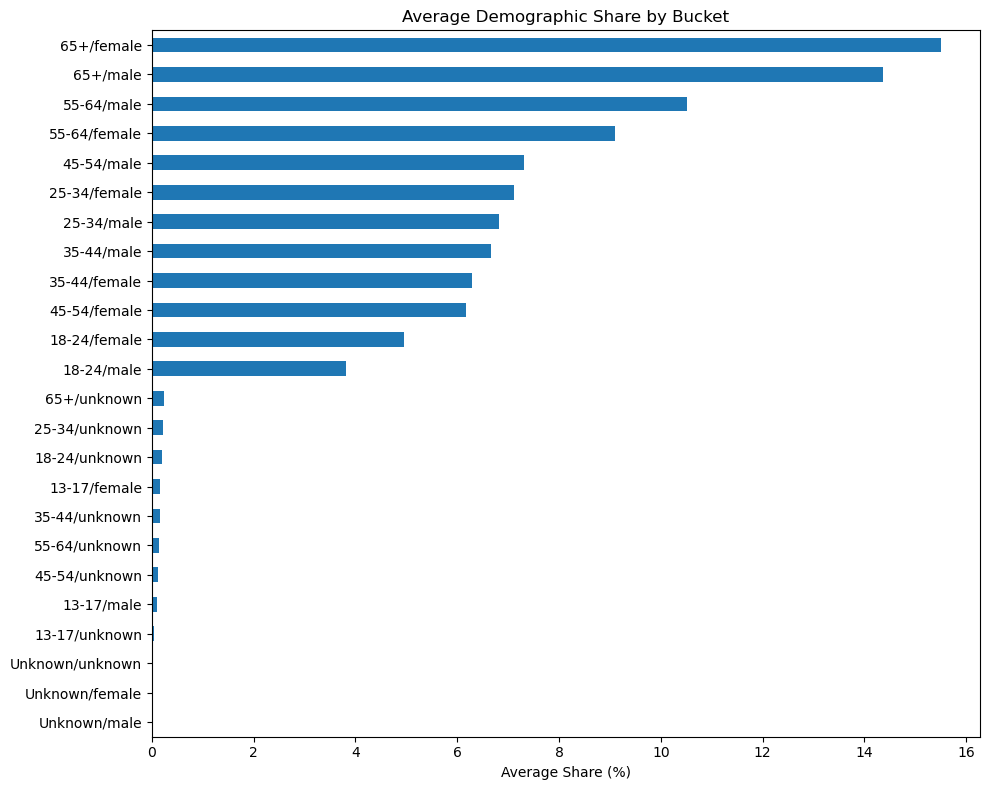

In [113]:
plt.figure(figsize=(10, 8))
demo_means.sort_values().plot(kind="barh")
plt.title("Average Demographic Share by Bucket")
plt.xlabel("Average Share (%)")
plt.tight_layout()
plt.show()

In [114]:
# Dominant demographic bucket per ad
demo_complete_df["dominant_demo"] = demo_complete_df[demo_cols].idxmax(axis=1)
dominant_counts = demo_complete_df["dominant_demo"].value_counts()

dominant_counts.head(15)

dominant_demo
65+/female       17318
65+/male         11807
55-64/male        5935
25-34/female      4616
18-24/female      4304
25-34/male        4110
35-44/female      3548
35-44/male        3523
55-64/female      2522
45-54/male        2233
18-24/male        1632
45-54/female      1475
13-17/female       166
13-17/male          35
18-24/unknown       32
Name: count, dtype: int64

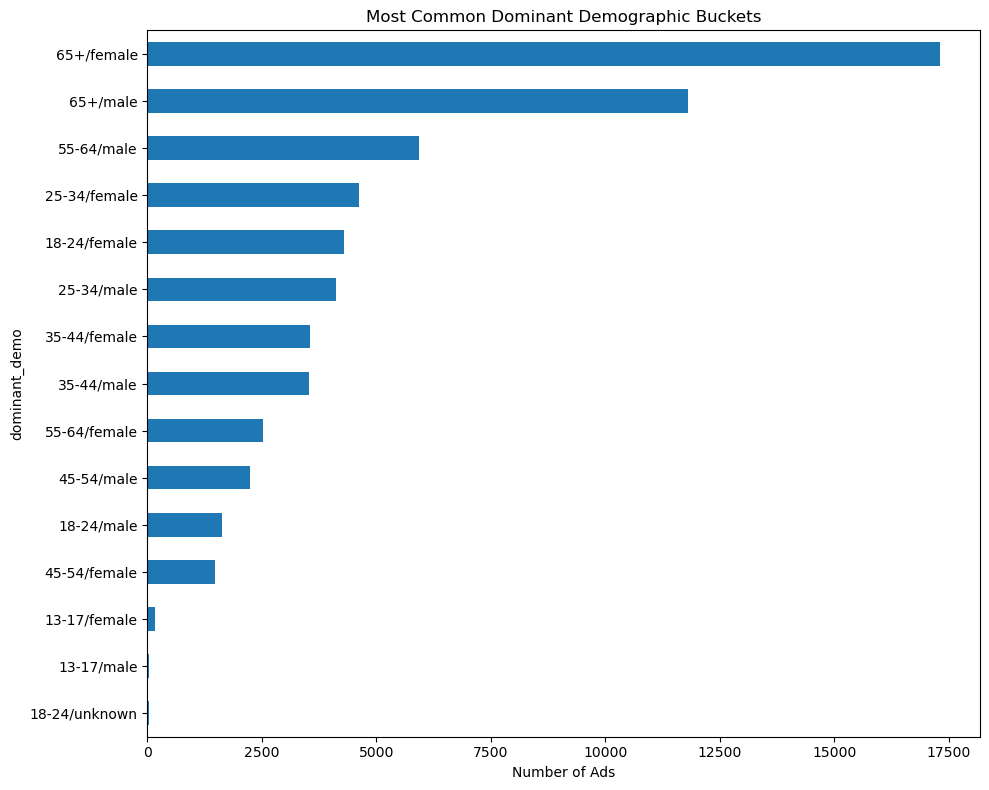

In [115]:
plt.figure(figsize=(10, 8))
dominant_counts.head(15).sort_values().plot(kind="barh")
plt.title("Most Common Dominant Demographic Buckets")
plt.xlabel("Number of Ads")
plt.tight_layout()
plt.show()

In [116]:
# Aggregate age groups (female + male + unknown)
age_groups = ["13-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+", "Unknown"]

age_share = {}
for age in age_groups:
    age_cols = [c for c in demo_cols if c.startswith(age + "/")]
    age_share[age] = demo_complete_df[age_cols].mean().sum()

age_share = pd.Series(age_share).sort_values(ascending=False)
age_share

65+        30.091826
55-64      19.768556
25-34      14.138738
45-54      13.622851
35-44      13.117298
18-24       8.961926
13-17       0.298470
Unknown     0.000212
dtype: float64

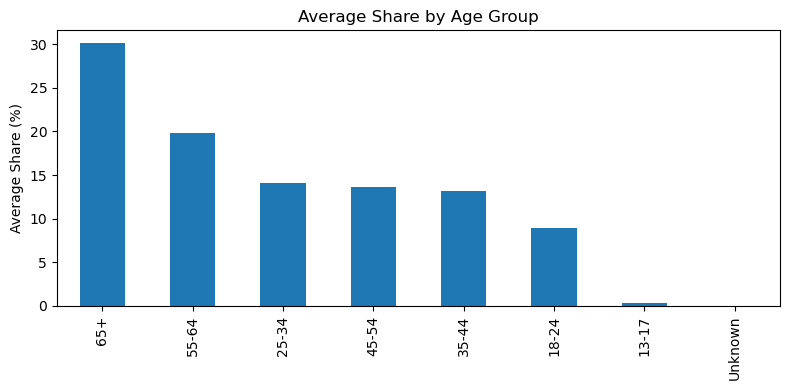

In [117]:
plt.figure(figsize=(8, 4))
age_share.plot(kind="bar")
plt.title("Average Share by Age Group")
plt.ylabel("Average Share (%)")
plt.tight_layout()
plt.show()

In [118]:
# Gender balance across complete demographic rows
gender_groups = ["female", "male", "unknown"]
gender_share = {}

for gender in gender_groups:
    gcols = [c for c in demo_cols if c.endswith("/" + gender)]
    gender_share[gender] = demo_complete_df[gcols].mean().sum()

gender_share = pd.Series(gender_share)
gender_share

female     49.288247
male       49.586681
unknown     1.124949
dtype: float64

In [ ]:
# Time patterns
monthly = (df.groupby("delivery_month")[["spend_mid", "impressions_mid"]].sum().sort_index())

monthly.tail(12)

,spend_mid,impressions_mid
delivery_month,,
2025-01,661539.5,32630794.0
2025-02,926648.0,28513907.5
2025-03,1057484.5,31219894.5
2025-04,1932391.0,26215296.0
2025-05,872807.0,21899408.5
2025-06,567486.0,21810887.5
2025-07,577415.5,20249675.0
2025-08,755743.0,28019395.5
2025-09,2060775.0,24479830.5


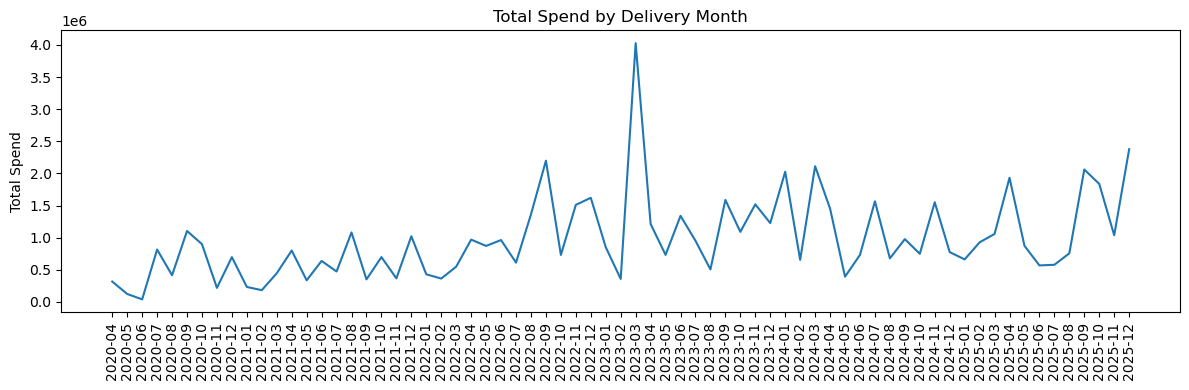

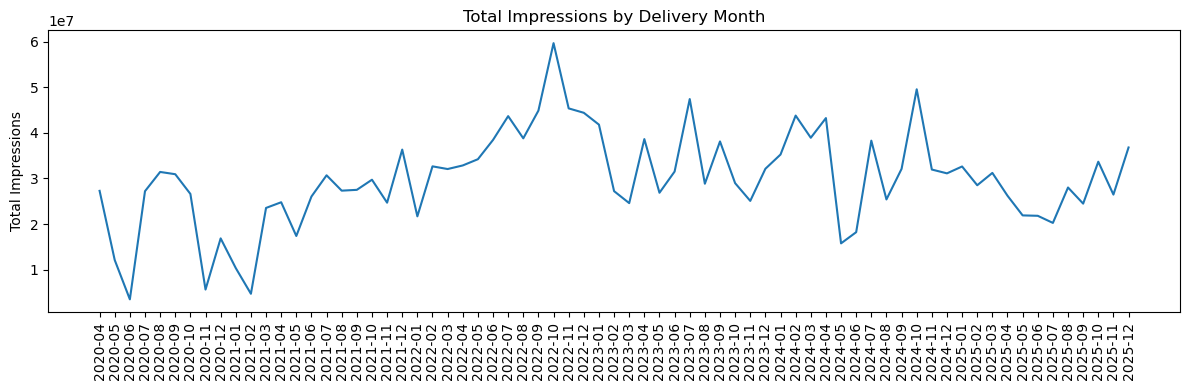

In [120]:
plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly["spend_mid"])
plt.xticks(rotation=90)
plt.title("Total Spend by Delivery Month")
plt.ylabel("Total Spend")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly["impressions_mid"])
plt.xticks(rotation=90)
plt.title("Total Impressions by Delivery Month")
plt.ylabel("Total Impressions")
plt.tight_layout()
plt.show()

In [121]:
# Top months
top_spend_months = monthly["spend_mid"].sort_values(ascending=False).head(10)
top_impression_months = monthly["impressions_mid"].sort_values(ascending=False).head(10)

print("Top months by total spend")
display(top_spend_months)

print("Top months by total impressions")
display(top_impression_months)

Top months by total spend


delivery_month
2023-03    4027544.5
2025-12    2375967.0
2022-09    2198242.5
2024-03    2111973.0
2025-09    2060775.0
2024-01    2025938.0
2025-04    1932391.0
2025-10    1835955.5
2022-12    1620214.5
2023-09    1587191.0
Name: spend_mid, dtype: float64

Top months by total impressions


delivery_month
2022-10    59694890.5
2024-10    49572928.5
2023-07    47428371.0
2022-11    45377871.0
2022-09    44892357.0
2022-12    44412273.5
2024-02    43800390.0
2022-07    43677340.5
2024-04    43250955.5
2023-01    41812807.5
Name: impressions_mid, dtype: float64

In [ ]:
# Compact insight tables

insight_missingness = missing.loc[["ad_creative_link_descriptions", "bylines", "ad_creative_link_titles",
                                   "ad_creative_link_captions", "ad_creative_bodies", "impressions_upper", "spend_upper"], :].sort_values("missing_pct", ascending=False)

insight_missingness

,missing_count,missing_pct
ad_creative_link_descriptions,23986,32.289157
bylines,13717,18.465370
ad_creative_link_titles,9375,12.620314
ad_creative_link_captions,7347,9.890287
ad_creative_bodies,2420,3.257724
impressions_upper,810,1.090395
spend_upper,4,0.005385


In [123]:
insight_summary = pd.Series({
    "rows": len(df),
    "cols": df.shape[1],
    "demo_complete_pct": df["demo_complete"].mean() * 100,
    "audience_mode_pct": (df["audience_size_lower"] == df["audience_size_lower"].mode().iloc[0]).mean() * 100,
    "median_impressions_mid": df["impressions_mid"].median(),
    "p99_impressions_mid": df["impressions_mid"].quantile(0.99),
    "max_impressions_mid": df["impressions_mid"].max(),
    "median_spend_mid": df["spend_mid"].median(),
    "p99_spend_mid": df["spend_mid"].quantile(0.99),
    "max_spend_mid": df["spend_mid"].max(),
    "median_delivery_lag": df["delivery_lag_days"].median(),
    "p99_delivery_lag": df["delivery_lag_days"].quantile(0.99),
    "max_delivery_lag": df["delivery_lag_days"].max(),
    "pearson_spend_impressions": df["spend_mid"].corr(df["impressions_mid"], method="pearson"),
    "spearman_spend_impressions": df["spend_mid"].corr(df["impressions_mid"], method="spearman"),})

insight_summary

rows                           74285.000000
cols                              53.000000
demo_complete_pct                 85.201588
audience_mode_pct                 99.998654
median_impressions_mid          2499.500000
p99_impressions_mid           549999.500000
max_impressions_mid           949999.500000
median_spend_mid                  49.500000
p99_spend_mid                  12499.500000
max_spend_mid                 949999.500000
median_delivery_lag                0.000000
p99_delivery_lag                  10.000000
max_delivery_lag                 204.000000
pearson_spend_impressions          0.103553
spearman_spend_impressions         0.750836
dtype: float64

In [124]:
# Summary printout

print(f"- Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"- Demographic-complete rows: {df['demo_complete'].mean()*100:.2f}%")
print(f"- audience_size_lower mode share: {(df['audience_size_lower'] == df['audience_size_lower'].mode().iloc[0]).mean()*100:.4f}%")
print(f"- Median impressions_mid: {df['impressions_mid'].median():,.1f}")
print(f"- 99th percentile impressions_mid: {df['impressions_mid'].quantile(0.99):,.1f}")
print(f"- Max impressions_mid: {df['impressions_mid'].max():,.1f}")
print(f"- Median spend_mid: {df['spend_mid'].median():,.1f}")
print(f"- 99th percentile spend_mid: {df['spend_mid'].quantile(0.99):,.1f}")
print(f"- Max spend_mid: {df['spend_mid'].max():,.1f}")
print(f"- Pearson(spend_mid, impressions_mid): {df['spend_mid'].corr(df['impressions_mid'], method='pearson'):.4f}")
print(f"- Spearman(spend_mid, impressions_mid): {df['spend_mid'].corr(df['impressions_mid'], method='spearman'):.4f}")
print(f"- Highest-spend month: {monthly['spend_mid'].idxmax()} with total spend {monthly['spend_mid'].max():,.1f}")

- Dataset shape: 74,285 rows x 53 columns
- Demographic-complete rows: 85.20%
- audience_size_lower mode share: 99.9987%
- Median impressions_mid: 2,499.5
- 99th percentile impressions_mid: 549,999.5
- Max impressions_mid: 949,999.5
- Median spend_mid: 49.5
- 99th percentile spend_mid: 12,499.5
- Max spend_mid: 949,999.5
- Pearson(spend_mid, impressions_mid): 0.1036
- Spearman(spend_mid, impressions_mid): 0.7508
- Highest-spend month: 2023-03 with total spend 4,027,544.5
